# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [31]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [32]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

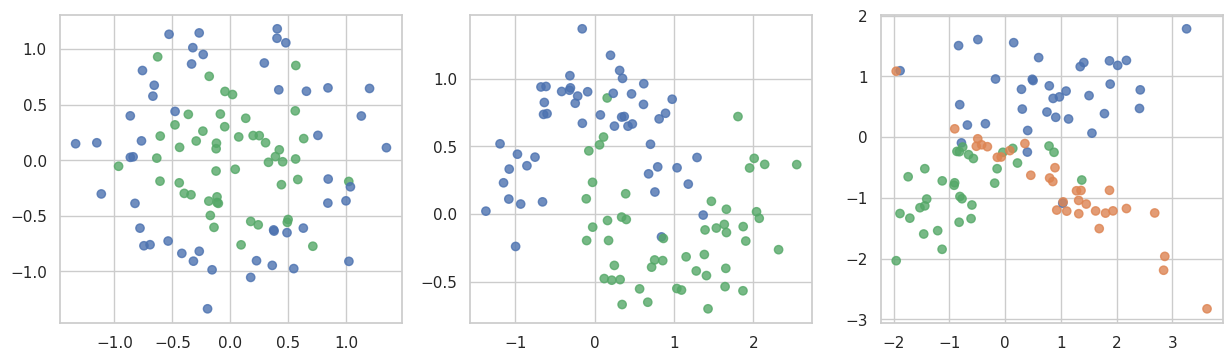

In [33]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [34]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

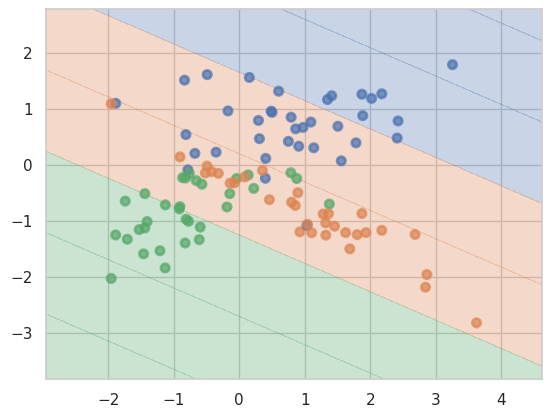

In [35]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Dataset: Circles         | Train Acc: 1.0000 | Test Acc: 0.7333 | Разница: 0.2667
Dataset: Moons           | Train Acc: 1.0000 | Test Acc: 0.8667 | Разница: 0.1333
Dataset: Classification  | Train Acc: 1.0000 | Test Acc: 0.8333 | Разница: 0.1667


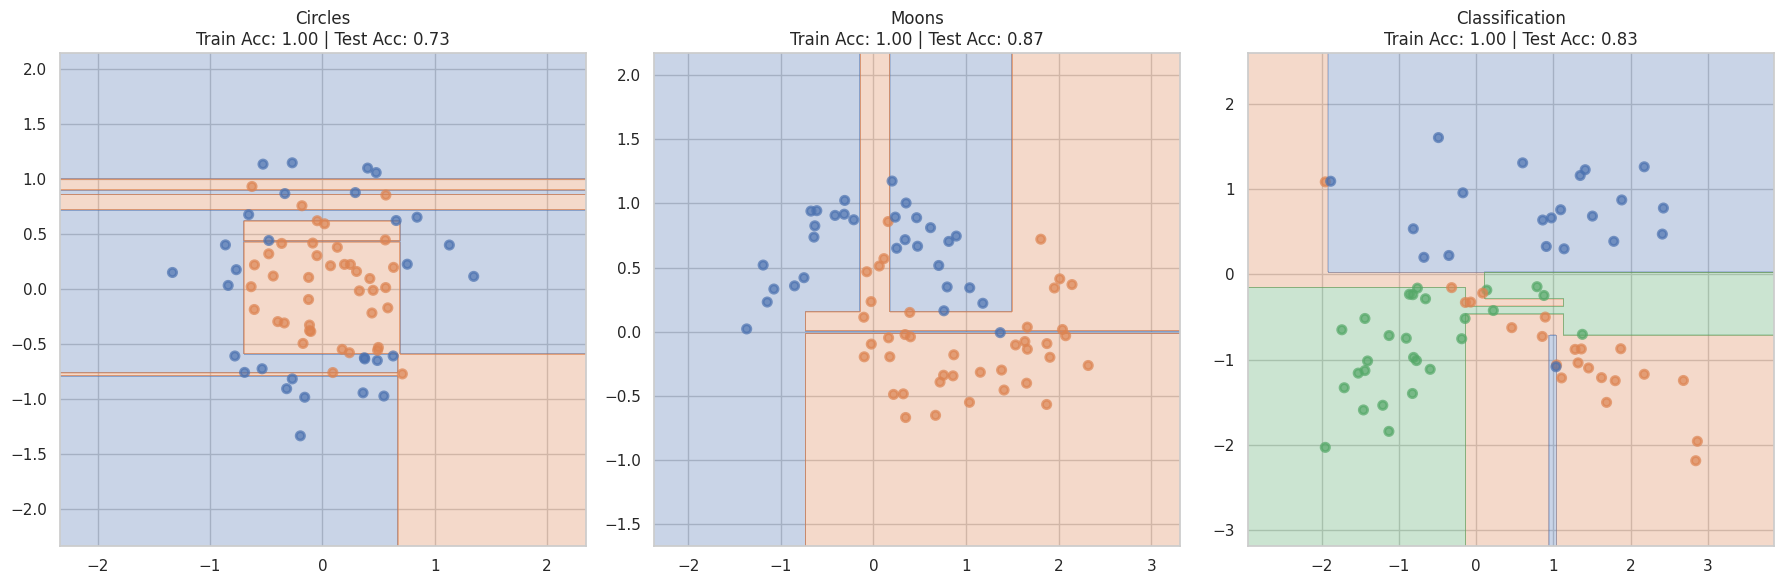

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_circles, make_moons, make_blobs

sns.set(style="whitegrid")

def plot_surface(clf, X, y, ax=None):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    if ax is None:
        ax = plt.gca()

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

dataset_names = ["Circles", "Moons", "Classification"]

plt.figure(figsize=(18, 6))

for i, (dataset, name) in enumerate(zip(datasets, dataset_names)):
    X, y = dataset

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    ax = plt.subplot(1, 3, i + 1)
    plot_surface(clf, X_train, y_train, ax=ax)

    ax.set_title(f"{name}\nTrain Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Dataset: {name:15} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Разница: {train_acc - test_acc:.4f}")

plt.tight_layout()
plt.show()

__Ответ:__ Для всех трёх датасетов решающие деревья, обученные с параметрами по умолчанию, показали идеальное качество на тренировочной выборке, что говорит о полном запоминании данных. Однако на тестовых выборках качество заметно ниже: от 0.73 до 0.87. Такое расхождение между train и test говорит о том, что модели сильно переобучились.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

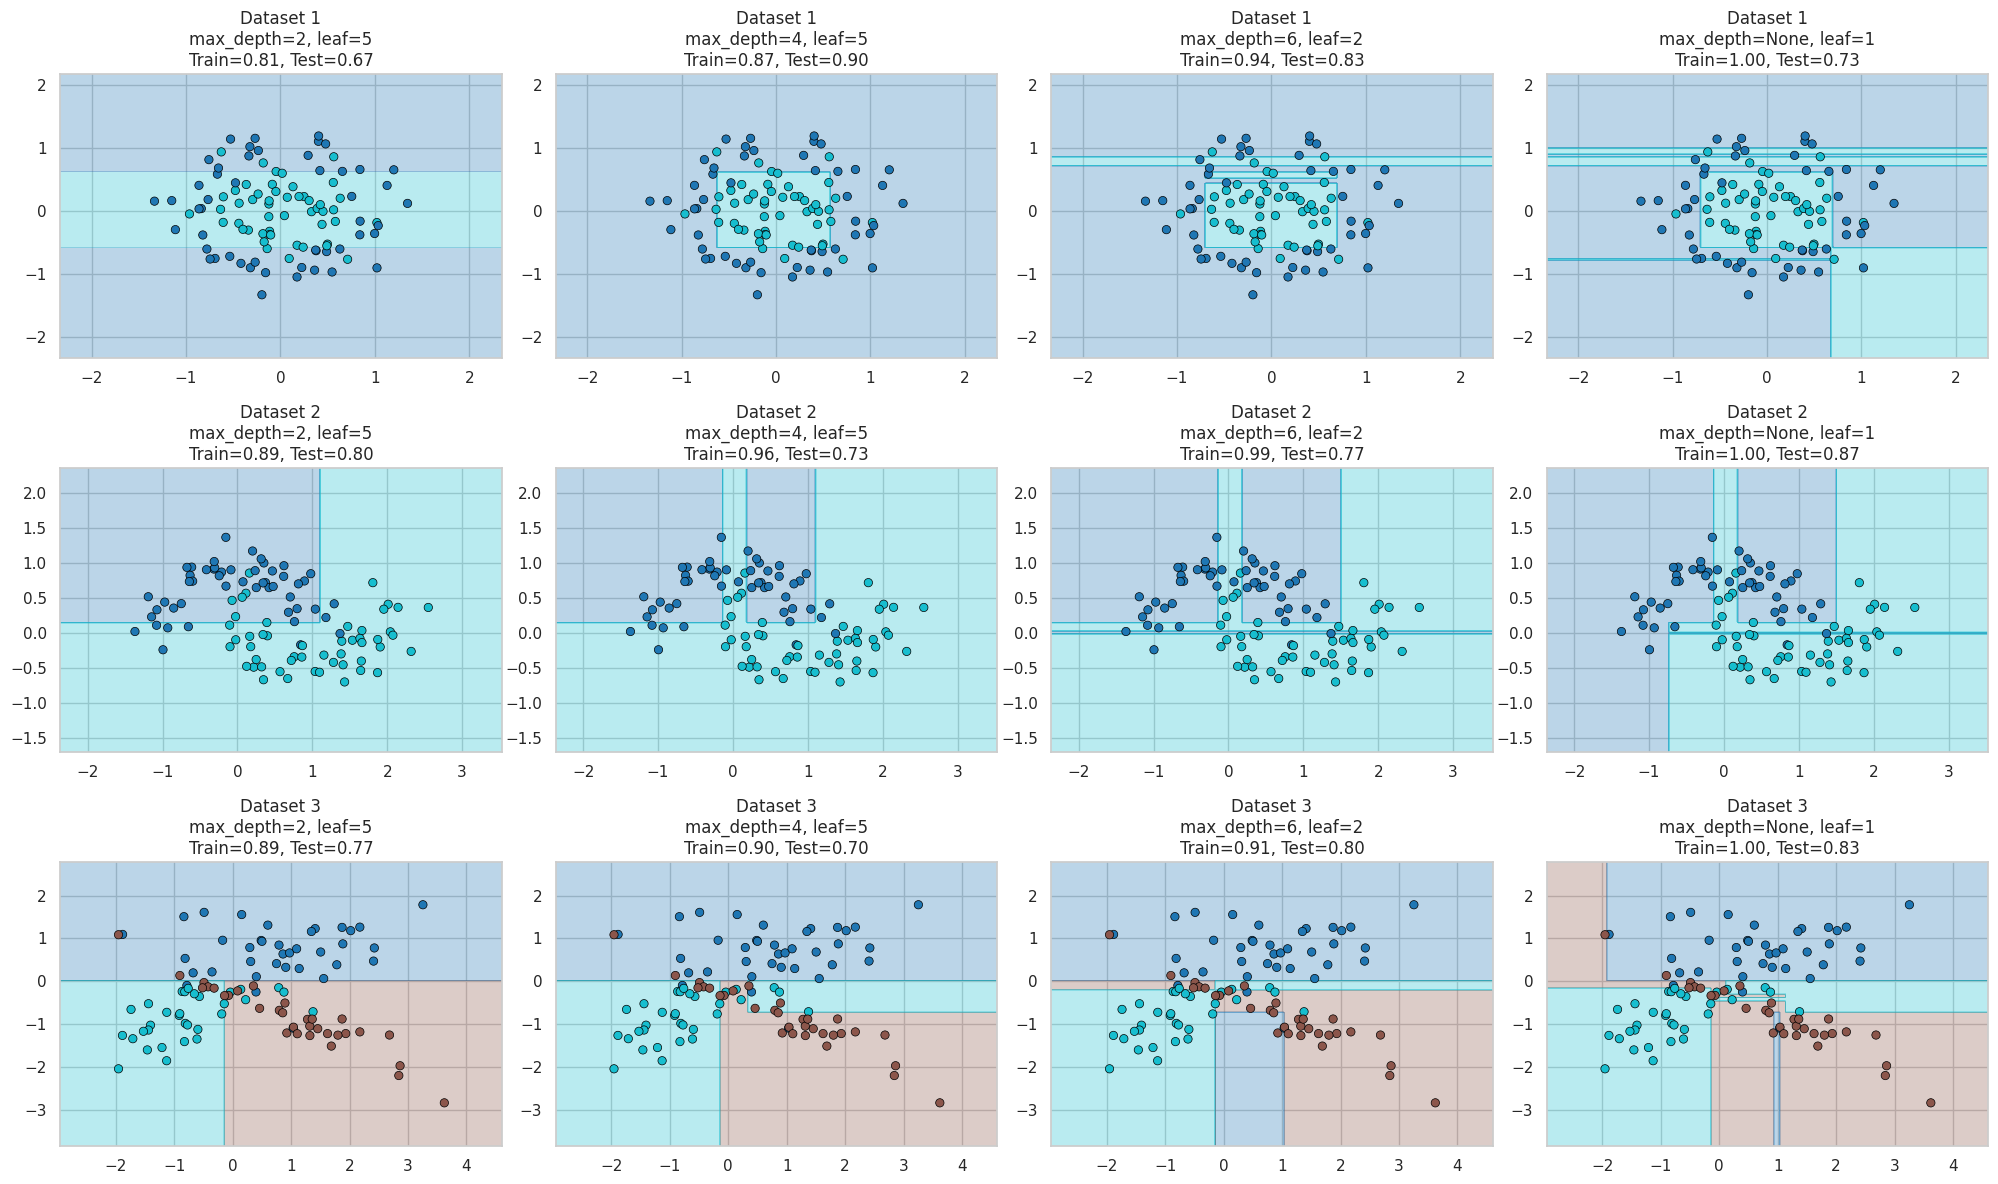

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

def generate_palette(n):
    cmap = plt.cm.get_cmap("tab10", n)
    return [cmap(i) for i in range(n)]

def plot_surface(clf, X, y, ax):
    palette = generate_palette(len(np.unique(y)))
    cmap = ListedColormap(palette)

    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    ax.scatter(
        X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='black', linewidths=0.5
    )

param_grid = [
    {"max_depth": 2, "min_samples_leaf": 5},
    {"max_depth": 4, "min_samples_leaf": 5},
    {"max_depth": 6, "min_samples_leaf": 2},
    {"max_depth": None, "min_samples_leaf": 1}  # без регуляризации
]

fixed_random_state = 42

all_results = []

fig, axes = plt.subplots(len(datasets), len(param_grid), figsize=(20, 12))

for row_idx, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=fixed_random_state
    )

    for col_idx, params in enumerate(param_grid):
        clf = DecisionTreeClassifier(
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42
        )
        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        all_results.append((row_idx, params, train_acc, test_acc))

        ax = axes[row_idx, col_idx]
        plot_surface(clf, X, y, ax)
        ax.set_title(
            f"Dataset {row_idx+1}\n"
            f"max_depth={params['max_depth']}, leaf={params['min_samples_leaf']}\n"
            f"Train={train_acc:.2f}, Test={test_acc:.2f}"
        )

plt.tight_layout()
plt.show()

__Ответ:__ Регуляризация сильно влияет на работу решающих деревьев. При небольших значениях max_depth и больших min_samples_leaf дерево становится проще, разделяющая поверхность — гладкой, и переобучение уменьшается. Если же сделать дерево слишком простым, появляется недообучение.

При увеличении глубины дерево начинает “запоминать” обучающую выборку, поверхность становится рваной, а тестовая точность падает — это переобучение.

Для разных датасетов эффект проявляется по-разному: более простые данные лучше реагируют на регуляризацию, а в более сложных датасетах слишком сильные ограничения быстро ухудшают качество.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

In [23]:
import numpy as np

def find_best_split(feature_vector, target_vector):
    sorted_idx = np.argsort(feature_vector)
    f_sorted = feature_vector[sorted_idx]
    t_sorted = target_vector[sorted_idx]

    diffs = f_sorted[1:] != f_sorted[:-1]
    if not np.any(diffs):
        return np.array([]), np.array([]), f_sorted[0], -np.inf

    thresholds = (f_sorted[1:][diffs] + f_sorted[:-1][diffs]) / 2

    t_cumsum = np.cumsum(t_sorted)
    n_total = len(t_sorted)
    total_1 = t_cumsum[-1]
    total_0 = n_total - total_1

    left_counts = t_cumsum[:-1][diffs]
    left_sizes = np.arange(1, n_total)[diffs]
    left_1 = left_counts
    left_0 = left_sizes - left_1

    right_1 = total_1 - left_1
    right_0 = total_0 - left_0
    right_sizes = n_total - left_sizes

    H_left = 1 - (left_1 / left_sizes)**2 - (left_0 / left_sizes)**2
    H_right = 1 - (right_1 / right_sizes)**2 - (right_0 / right_sizes)**2

    ginis = - (left_sizes / n_total) * H_left - (right_sizes / n_total) * H_right

    max_idx = np.argmax(ginis)
    threshold_best = thresholds[max_idx]
    gini_best = ginis[max_idx]

    return thresholds, ginis, threshold_best, gini_best

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

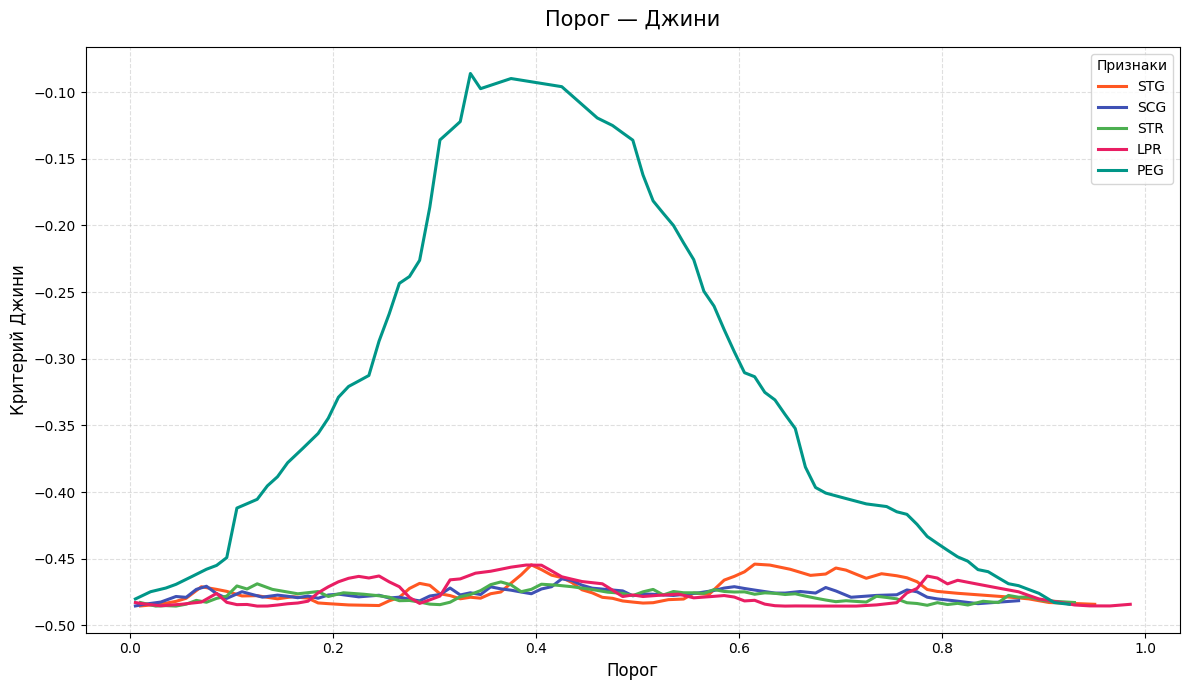

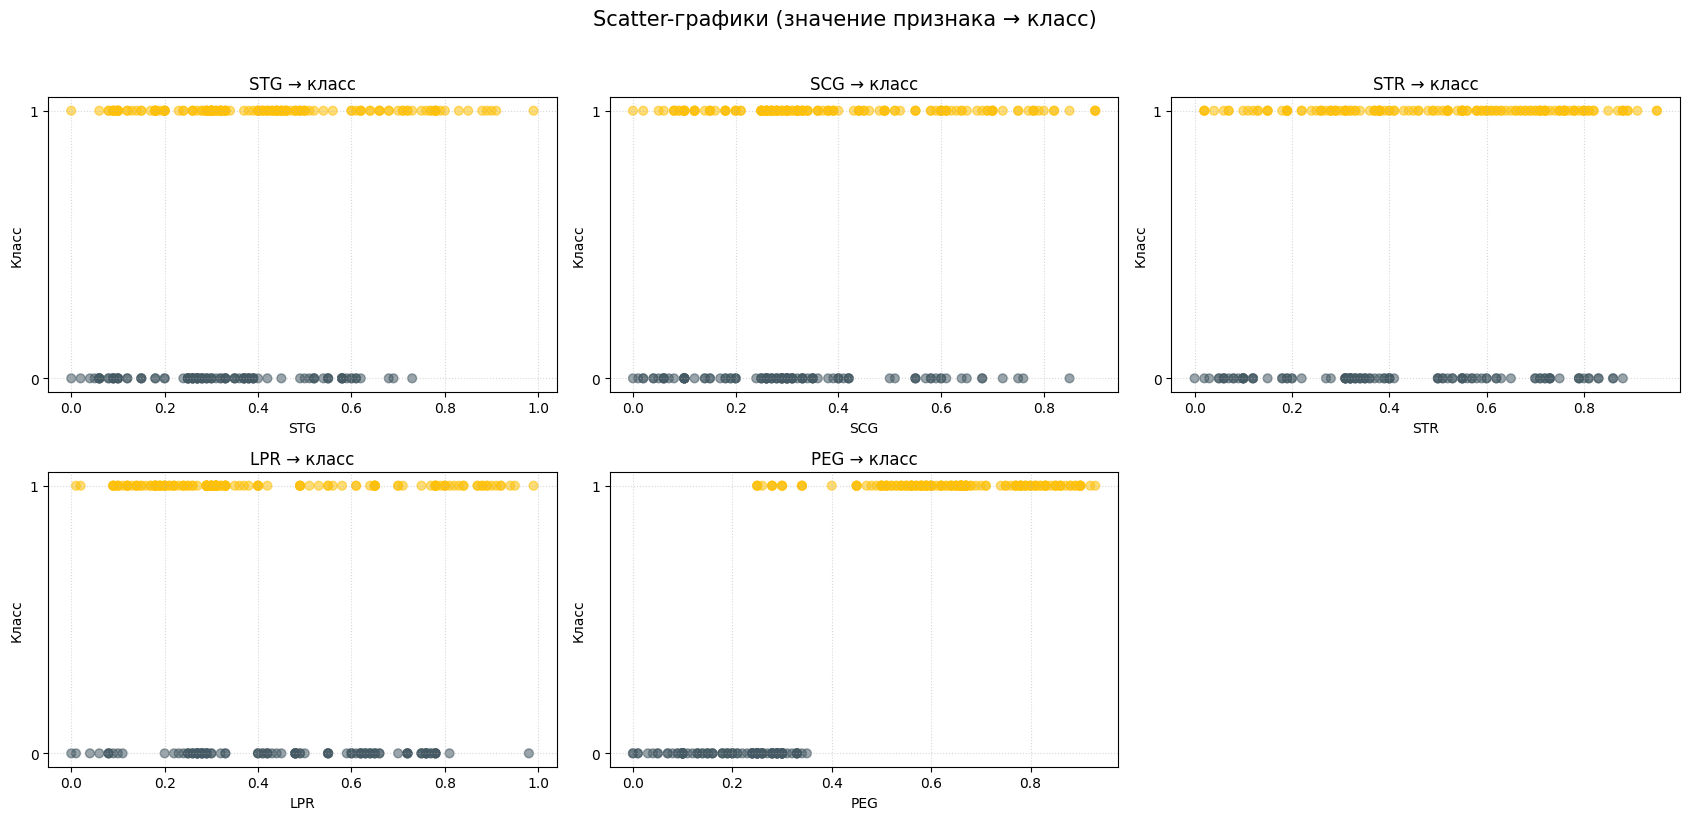

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/students.csv")

features = df.columns[:5]
target = df.columns[5]

colors = ["#FF5722", "#3F51B5", "#4CAF50", "#E91E63", "#009688"]

plt.figure(figsize=(12, 7))
plt.style.use("default")

for feat, col in zip(features, colors):
    thresholds, ginis, _, _ = find_best_split(df[feat].values, df[target].values)
    plt.plot(thresholds, ginis, label=feat, color=col, linewidth=2.2)

plt.xlabel("Порог", fontsize=12)
plt.ylabel("Критерий Джини", fontsize=12)
plt.title("Порог — Джини", fontsize=15, pad=15)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Признаки")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(17, 8))

axs = axs.flatten()

for i, feat in enumerate(features):
    axs[i].scatter(df[feat], df[target], alpha=0.55,
                   s=40,
                   c=df[target].map({0: "#455A64", 1: "#FFC107"}))
    axs[i].set_xlabel(feat)
    axs[i].set_ylabel("Класс")
    axs[i].set_yticks([0, 1])
    axs[i].set_title(f"{feat} → класс", fontsize=12)
    axs[i].grid(True, linestyle=":", alpha=0.5)

axs[-1].axis("off")

plt.suptitle("Scatter-графики (значение признака → класс)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Деление нужно производить по тому признаку, у которого кривая критерия Джини имеет самый глубокий минимум — именно он лучше всего разделяет классы. Это обычно согласуется со scatter-графиками: у лучшего признака классы на графике заметно разделяются по значениям, формируя почти отдельные области. У «хороших» признаков кривая Джини имеет вид резкого провала (ярко выраженный минимум), что означает почти идеальный порог для разделения. У «плохих» признаков кривая почти плоская, без выраженных минимумов — классы сильно перемешаны, и разделение по порогу почти невозможно.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

In [ ]:
import numpy as np
from collections import Counter


class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf


    def _fit_node(self, sub_X, sub_y, node):

        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if sub_X.shape[0] == 0:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best = None
        threshold_best = None
        gini_best = None
        split_best = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]

            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])

                ratios = {}
                for cat in counts:
                    ratio = clicks.get(cat, 0) / counts[cat]
                    ratios[cat] = ratio

                sorted_categories = [cat for cat, r in sorted(ratios.items(), key=lambda x: x[1])]
                category_to_num = {cat: i for i, cat in enumerate(sorted_categories)}

                feature_vector = np.array([category_to_num[x] for x in sub_X[:, feature]])

            else:
                raise ValueError("Unknown feature type")

            if len(np.unique(feature_vector)) < 2:
                continue

            thresholds, ginis, _, _ = find_best_split(feature_vector, sub_y)

            idx = np.argmin(ginis)
            gini = ginis[idx]
            threshold = thresholds[idx]

            if gini_best is None or gini < gini_best:
                gini_best = gini
                feature_best = feature

                if feature_type == "real":
                    threshold_best = threshold
                    split_best = feature_vector < threshold

                else:
                    left_cats = [cat for cat, num in category_to_num.items() if num < threshold]
                    threshold_best = left_cats
                    split_best = np.array([x in left_cats for x in sub_X[:, feature]])

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}

        self._fit_node(sub_X[split_best], sub_y[split_best], node["left_child"])
        self._fit_node(sub_X[~split_best], sub_y[~split_best], node["right_child"])



    def _predict_node(self, x, node):

        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        value = x[feature]

        if self._feature_types[feature] == "real":
            if value < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

        else:
            if value in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])



    def fit(self, X, y):
        self._fit_node(X, y, self._tree)


    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

encoders = []
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders.append(le)

y = df[0]
X = df.drop(columns=[0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, shuffle=True
)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

Accuracy: 1.0
Tree depth: 7
Number of leaves: 18


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

In [11]:
import numpy as np
from collections import Counter

class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf


    def _fit_node(self, sub_X, sub_y, node, depth=0):

        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if sub_X.shape[0] < self._min_samples_split or \
           (self._max_depth is not None and depth >= self._max_depth):
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best = None
        threshold_best = None
        gini_best = None
        split_best = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]

            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])

                ratios = {cat: clicks.get(cat, 0)/counts[cat] for cat in counts}
                sorted_categories = [cat for cat, r in sorted(ratios.items(), key=lambda x: x[1])]
                category_to_num = {cat: i for i, cat in enumerate(sorted_categories)}
                feature_vector = np.array([category_to_num[x] for x in sub_X[:, feature]])

            else:
                raise ValueError("Unknown feature type")

            if len(np.unique(feature_vector)) < 2:
                continue

            thresholds, ginis, _, _ = find_best_split(feature_vector, sub_y)

            idx = np.argmin(ginis)
            gini = ginis[idx]
            threshold = thresholds[idx]

            if feature_type == "real":
                split_tmp = feature_vector < threshold
            else:
                left_cats = [cat for cat, num in category_to_num.items() if num < threshold]
                split_tmp = np.array([x in left_cats for x in sub_X[:, feature]])

            if split_tmp.sum() < self._min_samples_leaf or (~split_tmp).sum() < self._min_samples_leaf:
                continue

            if gini_best is None or gini < gini_best:
                gini_best = gini
                feature_best = feature
                threshold_best = threshold if feature_type == "real" else left_cats
                split_best = split_tmp

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}

        self._fit_node(sub_X[split_best], sub_y[split_best], node["left_child"], depth+1)
        self._fit_node(sub_X[~split_best], sub_y[~split_best], node["right_child"], depth+1)


    def _predict_node(self, x, node):

        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        value = x[feature]

        if self._feature_types[feature] == "real":
            if value < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            if value in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])


    def fit(self, X, y):
        self._fit_node(X, y, self._tree, depth=0)


    def predict(self, X):
        return np.array([self._predict_node(x, self._tree) for x in X])

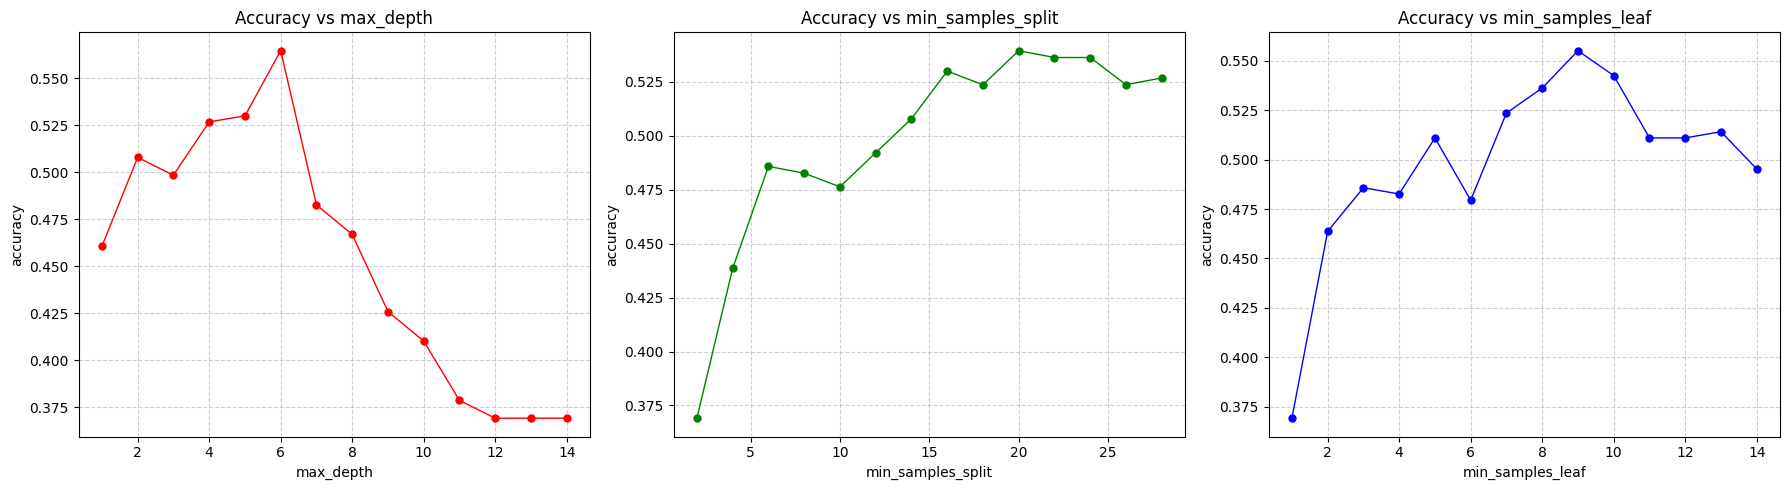

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')

df = pd.read_csv("datasets/tic-tac-toe-endgame.csv", header=None)

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

y = df[0].values
X = df.drop(columns=[0]).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

feature_types = ["categorical"] * X.shape[1]

depths = range(1, 15)
accs_depth = []
for d in depths:
    tree = DecisionTree(feature_types, max_depth=d)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    accs_depth.append(accuracy_score(y_test, y_pred))

splits = range(2, 30, 2)
accs_split = []
for s in splits:
    tree = DecisionTree(feature_types, min_samples_split=s)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    accs_split.append(accuracy_score(y_test, y_pred))

leaves = range(1, 15)
accs_leaf = []
for l in leaves:
    tree = DecisionTree(feature_types, min_samples_leaf=l)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    accs_leaf.append(accuracy_score(y_test, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(depths, accs_depth, marker='o', color='red', linewidth=1, markersize=5)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy vs max_depth")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(splits, accs_split, marker='o', color='green', linewidth=1, markersize=5)
axes[1].set_xlabel("min_samples_split")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy vs min_samples_split")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(leaves, accs_leaf, marker='o', color='blue', linewidth=1, markersize=5)
axes[2].set_xlabel("min_samples_leaf")
axes[2].set_ylabel("accuracy")
axes[2].set_title("Accuracy vs min_samples_leaf")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin
from collections import Counter

def find_best_split(feature_vector, target_vector):
    sorted_idx = np.argsort(feature_vector)
    f_sorted = feature_vector[sorted_idx]
    t_sorted = target_vector[sorted_idx]

    diffs = f_sorted[1:] != f_sorted[:-1]
    if not np.any(diffs):
        return np.array([]), np.array([]), None, None

    thresholds = (f_sorted[1:][diffs] + f_sorted[:-1][diffs]) / 2

    t_cumsum = np.cumsum(t_sorted)
    n_total = len(t_sorted)
    total_1 = t_cumsum[-1]
    total_0 = n_total - total_1

    left_counts = t_cumsum[:-1][diffs]
    left_sizes = np.arange(1, n_total)[diffs]
    left_1 = left_counts
    left_0 = left_sizes - left_1

    right_1 = total_1 - left_1
    right_0 = total_0 - left_0
    right_sizes = n_total - left_sizes

    H_left = 1 - (left_1 / left_sizes)**2 - (left_0 / left_sizes)**2
    H_right = 1 - (right_1 / right_sizes)**2 - (right_0 / right_sizes)**2

    ginis = - (left_sizes / n_total) * H_left - (right_sizes / n_total) * H_right

    idx = np.argmax(ginis)
    return thresholds, ginis, thresholds[idx], ginis[idx]


class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if sub_X.shape[0] < self._min_samples_split or \
           (self._max_depth is not None and depth >= self._max_depth):
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best = None
        threshold_best = None
        gini_best = None
        split_best = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]

            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])

                target_class_for_ratio = 1
                clicks = Counter(sub_X[sub_y == target_class_for_ratio, feature])

                ratios = {cat: clicks.get(cat, 0)/counts[cat] for cat in counts}
                sorted_categories = [cat for cat, r in sorted(ratios.items(), key=lambda x: x[1])]
                category_to_num = {cat: i for i, cat in enumerate(sorted_categories)}
                feature_vector = np.array([category_to_num[x] for x in sub_X[:, feature]])
            else:
                raise ValueError("Unknown feature type")

            if len(np.unique(feature_vector)) < 2:
                continue

            thresholds, ginis, _, _ = find_best_split(feature_vector, sub_y)

            if len(ginis) == 0: continue

            idx = np.argmax(ginis)
            gini = ginis[idx]
            threshold = thresholds[idx]

            if feature_type == "real":
                split_tmp = feature_vector < threshold
            else:
                left_cats = [cat for cat, num in category_to_num.items() if num < threshold]
                split_tmp = np.array([x in left_cats for x in sub_X[:, feature]])

            if split_tmp.sum() < self._min_samples_leaf or (~split_tmp).sum() < self._min_samples_leaf:
                continue

            if gini_best is None or gini > gini_best:
                gini_best = gini
                feature_best = feature
                threshold_best = threshold if feature_type == "real" else left_cats
                split_best = split_tmp

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split_best], sub_y[split_best], node["left_child"], depth+1)
        self._fit_node(sub_X[~split_best], sub_y[~split_best], node["right_child"], depth+1)

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        try:
            value = x[feature]
        except IndexError:
            return node.get("class", 0)

        if self._feature_types[feature] == "real":
            if value < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            if value in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, X, y):
        self._fit_node(X, y, self._tree, depth=0)

    def predict(self, X):
        return np.array([self._predict_node(x, self._tree) for x in X])


class SklearnWrapperDecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_types, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.feature_types = feature_types
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.model = None

    def fit(self, X, y):
        self.model = DecisionTree(
            feature_types=self.feature_types,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf
        )
        self.model.fit(np.array(X), np.array(y))
        return self

    def predict(self, X):
        return self.model.predict(np.array(X))

datasets_urls = {
    'mushrooms': 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data',
    'tic-tac-toe': 'https://archive.ics.uci.edu/ml/machine-learning-databases/tic-tac-toe/tic-tac-toe.data',
    'cars': 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data',
    'nursery': 'https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data'
}

data_prepared = {}
print("Загрузка данных...")

try:
    df_m = pd.read_csv(datasets_urls['mushrooms'], header=None)
    X_m = df_m.iloc[:, 1:]
    y_m = LabelEncoder().fit_transform(df_m.iloc[:, 0])
    for col in X_m.columns:
        X_m[col] = LabelEncoder().fit_transform(X_m[col])
    data_prepared['mushrooms'] = (X_m.values, y_m)
except Exception as e: print(f"Err: {e}")

try:
    df_t = pd.read_csv(datasets_urls['tic-tac-toe'], header=None)
    X_t = df_t.iloc[:, :-1]
    y_t = LabelEncoder().fit_transform(df_t.iloc[:, -1])
    for col in X_t.columns:
        X_t[col] = LabelEncoder().fit_transform(X_t[col])
    data_prepared['tic-tac-toe'] = (X_t.values, y_t)
except Exception as e: print(f"Err: {e}")

try:
    df_c = pd.read_csv(datasets_urls['cars'], header=None)
    X_c = df_c.iloc[:, :-1]
    y_c = df_c.iloc[:, -1].map({'unacc':0, 'acc':0, 'good':1, 'vgood':1}).values
    for col in X_c.columns:
        X_c[col] = LabelEncoder().fit_transform(X_c[col])
    data_prepared['cars'] = (X_c.values, y_c)
except Exception as e: print(f"Err: {e}")

try:
    df_n = pd.read_csv(datasets_urls['nursery'], header=None)
    X_n = df_n.iloc[:, :-1]
    y_n = df_n.iloc[:, -1].map({'not_recom':0, 'recommend':0, 'very_recom':1, 'priority':1, 'spec_prior':1}).values
    for col in X_n.columns:
        X_n[col] = LabelEncoder().fit_transform(X_n[col])
    data_prepared['nursery'] = (X_n.values, y_n)
except Exception as e: print(f"Err: {e}")

results = []
scorer = make_scorer(accuracy_score)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
MAX_DEPTH = 10
MIN_SAMPLES_LEAF = 5

print("Старт валидации...")
for name, (X, y) in data_prepared.items():
    n_features = X.shape[1]

    dt_real = SklearnWrapperDecisionTree(["real"] * n_features, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
    score_real = cross_val_score(dt_real, X, y, cv=cv, scoring=scorer).mean()

    dt_cat = SklearnWrapperDecisionTree(["categorical"] * n_features, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
    score_cat = cross_val_score(dt_cat, X, y, cv=cv, scoring=scorer).mean()

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X)
    dt_ohe = SklearnWrapperDecisionTree(["real"] * X_ohe.shape[1], max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
    score_ohe = cross_val_score(dt_ohe, X_ohe, y, cv=cv, scoring=scorer).mean()

    sk_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
    score_sk = cross_val_score(sk_tree, X, y, cv=cv, scoring=scorer).mean()

    results.append({'dataset': name, 'DT_real': score_real, 'DT_cat': score_cat, 'DT_OHE': score_ohe, 'Sklearn': score_sk})

print(pd.DataFrame(results).set_index('dataset'))

Загрузка данных...


/tmp/ipython-input-1634762755.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_m[col] = LabelEncoder().fit_transform(X_m[col])
/tmp/ipython-input-1634762755.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_m[col] = LabelEncoder().fit_transform(X_m[col])
/tmp/ipython-input-1634762755.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

Старт валидации...
              DT_real    DT_cat    DT_OHE   Sklearn
dataset                                            
mushrooms    1.000000  1.000000  1.000000  1.000000
tic-tac-toe  0.837138  0.933202  0.934243  0.891414
cars         0.987851  0.985536  0.985529  0.988423
nursery      0.999846  0.999846  0.999846  0.999691


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:** Алгоритмы ранжируются по-разному: на датасете *tic-tac-toe* категориальные подходы DT_cat, DT_OHE значительно превосходят вещественный DT_real, так как признаки там неупорядоченные и ложный порядок вещественных чисел мешает дереву находить оптимальные разбиения, тогда как на ординальных данных cars, nursery все методы показывают схожие высокие результаты. Компонента случайности присутствует в разбиении кросс-валидации и выборе порогов при равном приросте информативности; снизить ее влияние можно фиксацией random_state, а улучшить работу алгоритмов — правильным выбором кодирования (OHE для номинальных, Label для ординальных) и подбором гиперпараметров (глубины, min_samples) под конкретную задачу.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

фух, сделал 🤯